# Phase 4: Exploratory Data Analysis

## Objectives

In this final phase, you will:

1. Conduct comprehensive univariate analysis
2. Perform bivariate analysis to understand feature relationships
3. Analyze the target variable distribution
4. Identify key patterns and insights in the data
5. Validate assumptions and feature engineering decisions
6. Create visualizations that tell the story of house prices
7. Prepare final recommendations for modeling

## Instructions

EDA is both an art and a science. Look for patterns, anomalies, and insights that will guide modeling decisions.

---
## Task 1: Import Libraries and Load Data

In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load feature-engineered data
df_engineered = pd.read_csv('Data/train_feature_engineered.csv')

# Load original cleaned data for categorical analysis
df_original = pd.read_csv('Data/train_cleaned.csv')

# Extract target variable
y = df_original['SalePrice']

# Print dataset shapes to verify
print(f"Feature-engineered data shape: {df_engineered.shape}")
print(f"Original cleaned data shape: {df_original.shape}")
print(f"Target variable shape: {y.shape}")
print("\nDataset loaded successfully!")

Feature-engineered data shape: (1429, 84)
Original cleaned data shape: (1429, 69)
Target variable shape: (1429,)

Dataset loaded successfully!


In [323]:
df_engineered.head(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,MoSold,SaleType,SaleCondition,TotalSF,TotalBathrooms,TotalPorchSF,FinishedBsmtSF,FinishedBsmtRatio,Basement_to_TotalArea,Garage_to_LivingArea,YearsSinceRemodel,GarageAge,HasSecondFloor,HasBasement,HasGarage,HasFireplace,HasPool,HasPorch,IsRemodeled,Quality_x_Area,Quality_x_Condition,Baths_x_Bedrooms,GarageCars_x_Area,OverallQual_Squared
0,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,2Story,7,5,2003,2003,Gable,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,150,856,Ex,Y,SBrkr,856,854,1710,1,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,2,WD,Normal,2566,3.5,61,706,0.824766,0.333593,0.320468,5,5,1,1,1,0,0,1,0,11970,35,10.5,3420,49
1,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,1Fam,1Story,6,8,1976,1976,Gable,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,284,1262,Ex,Y,SBrkr,1262,0,1262,0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,5,WD,Normal,2524,2.5,0,978,0.774960,0.500000,0.364501,31,31,0,1,1,1,0,0,0,7572,48,7.5,2524,36
2,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,2Story,7,5,2001,2002,Gable,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,434,920,Ex,Y,SBrkr,920,866,1786,1,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,9,WD,Normal,2706,3.5,42,486,0.528261,0.339985,0.340426,6,7,1,1,1,1,0,1,1,12502,35,10.5,3572,49
3,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,1Fam,2Story,7,5,1915,1970,Gable,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,540,756,Gd,Y,SBrkr,961,756,1717,1,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,2,WD,Abnorml,2473,2.0,307,216,0.285714,0.305702,0.373908,36,8,1,1,1,1,0,1,1,12019,35,6.0,5151,49
4,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,1Fam,2Story,8,5,2000,2000,Gable,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,490,1145,Ex,Y,SBrkr,1145,1053,2198,1,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,12,WD,Normal,3343,3.5,84,655,0.572052,0.342507,0.380346,8,8,1,1,1,1,0,1,0,17584,40,14.0,6594,64


### Step 2.1: Statistical Summary of Target Variable

In [ ]:
# TODO: Print comprehensive statistics for SalePrice

count = y.count()
mean = y.mean()
median = y.median()
std = y.std()
min_val = y.min()
max_val = y.max()
range_val = max_val - min_val

q1 = y.quantile(0.25)
q2 = y.quantile(0.50)
q3 = y.quantile(0.75)


skewness = stats.skew(y)
kurtosis = stats.kurtosis(y)
print("SALEPRICE – COMPREHENSIVE STATISTICS")
print("-" * 45)
print(f"Count:        {count}")
print(f"Mean:         ${mean:,.2f}")
print(f"Median:       ${median:,.2f}")
print(f"Std Dev:      ${std:,.2f}")
print(f"Min:          ${min_val:,.2f}")
print(f"Max:          ${max_val:,.2f}")
print(f"Range:        ${range_val:,.2f}")
print()
print(f"Q1 (25%):     ${q1:,.2f}")
print(f"Q2 (50%):     ${q2:,.2f}")
print(f"Q3 (75%):     ${q3:,.2f}")
print()
print(f"Skewness:     {skewness:.4f}")
print(f"Kurtosis:     {kurtosis:.4f}")

SALEPRICE – COMPREHENSIVE STATISTICS
---------------------------------------------
Count:        1429
Mean:         $176,780.21
Median:       $161,000.00
Std Dev:      $70,626.31
Min:          $34,900.00
Max:          $485,000.00
Range:        $450,100.00

Q1 (25%):     $129,500.00
Q2 (50%):     $161,000.00
Q3 (75%):     $210,000.00

Skewness:     1.2042
Kurtosis:     1.7617


### Step 2.2: Visualize Target Distribution

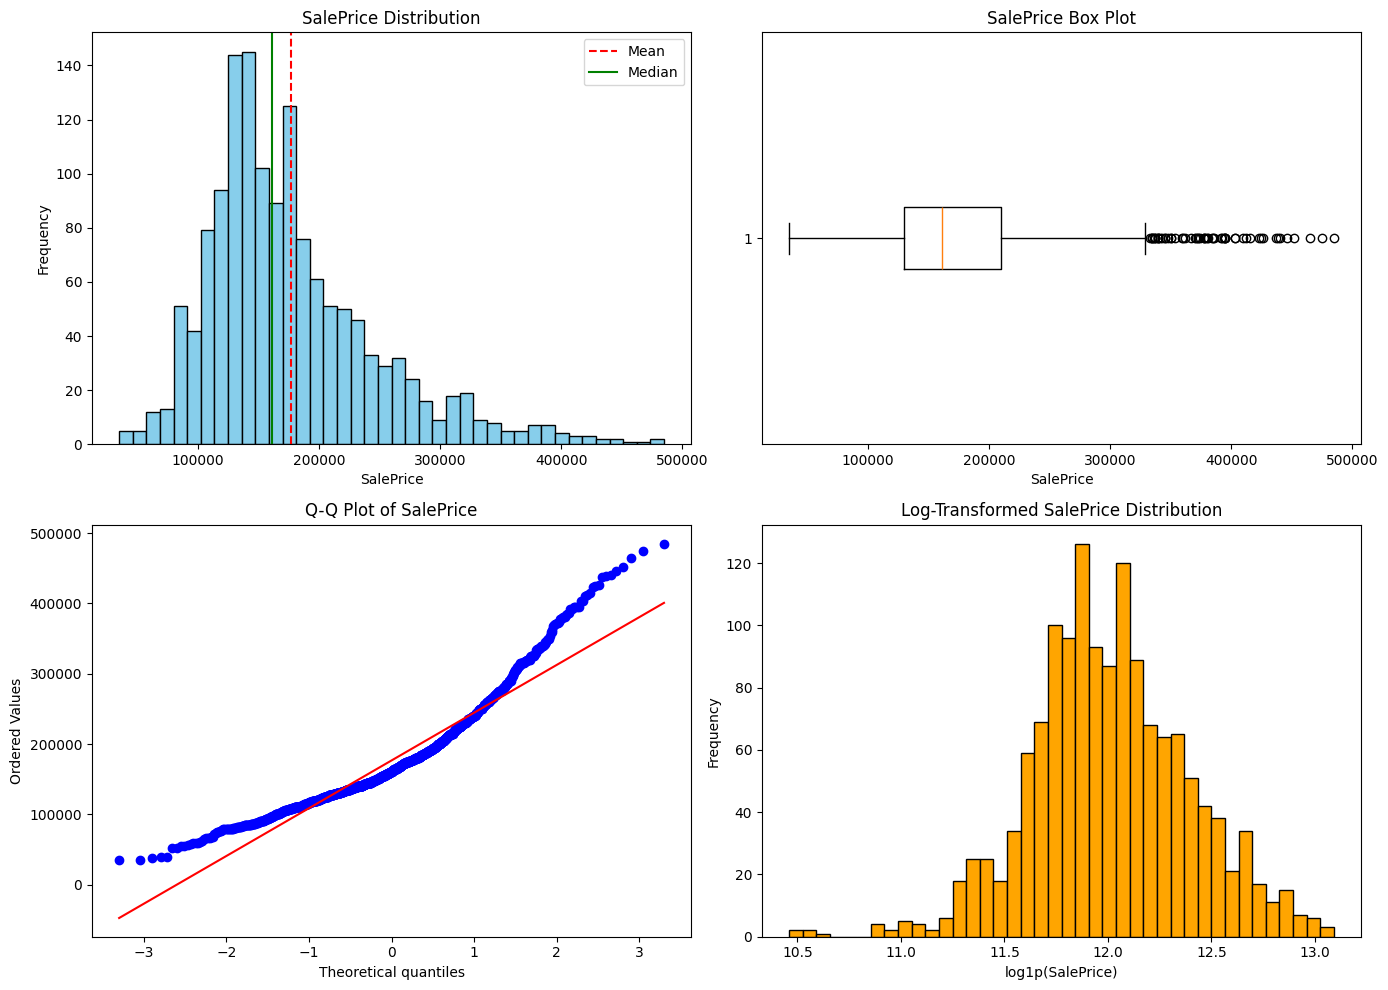

In [ ]:
# Create 2x2 subplot for target variable visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram with mean and median
axes[0, 0].hist(y, bins=40, color='skyblue', edgecolor='black')
axes[0, 0].axvline(y.mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].axvline(y.median(), color='green', linestyle='-', label='Median')
axes[0, 0].set_title('SalePrice Distribution')
axes[0, 0].set_xlabel('SalePrice')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# 2. Box plot
axes[0, 1].boxplot(y, vert=False)
axes[0, 1].set_title('SalePrice Box Plot')
axes[0, 1].set_xlabel('SalePrice')

# 3. Q-Q plot
stats.probplot(y, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of SalePrice')

# 4. Log-transformed histogram
y_log = np.log1p(y)
axes[1, 1].hist(y_log, bins=40, color='orange', edgecolor='black')
axes[1, 1].set_title('Log-Transformed SalePrice Distribution')
axes[1, 1].set_xlabel('log1p(SalePrice)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
skewness = stats.skew(y_log)


### Your Analysis:

Write your observations about the target variable:
- Is the distribution normal or skewed?
- Are there outliers?
- What price range do most houses fall into?
- Does log transformation improve normality?

---
## Task 3: Univariate Analysis - Numerical Features

Analyze individual numerical features.

In [ ]:
# Get numerical features

numerical_features = df_original.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Id' in numerical_features:
    numerical_features.remove('Id')

if 'SalePrice' in numerical_features:
    numerical_features.remove('SalePrice')

print(f"Number of numerical features being analyzed: {len(numerical_features)}")



Number of numerical features being analyzed: 35


### Step 3.1: Distribution Analysis of Key Numerical Features

Key numerical features selected:
['GrLivArea', 'TotalBsmtSF', 'LotArea', 'GarageArea', 'YearBuilt']


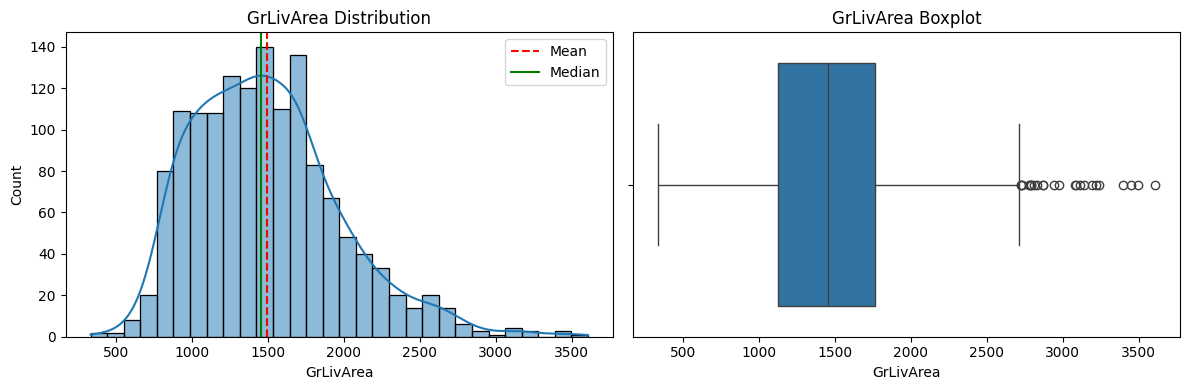

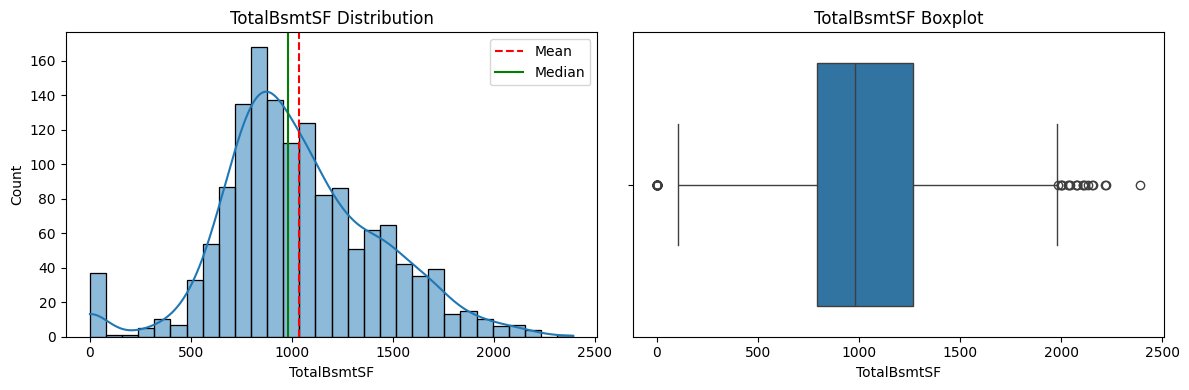

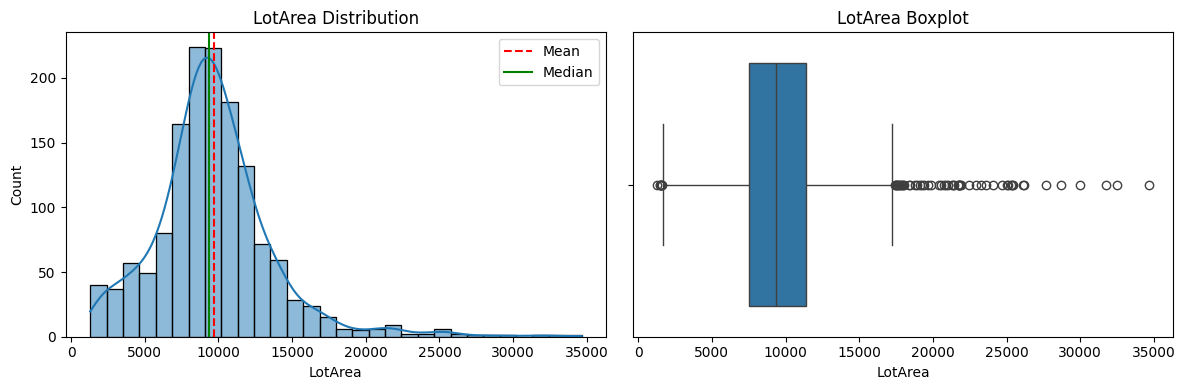

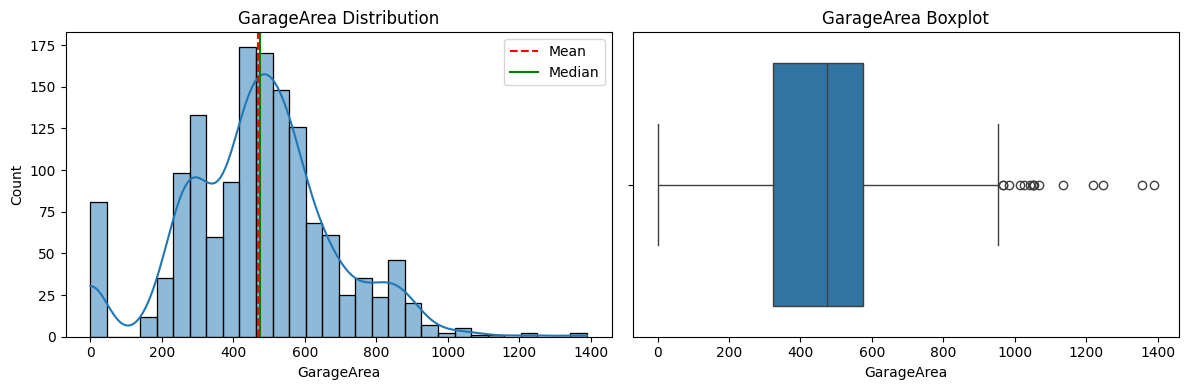

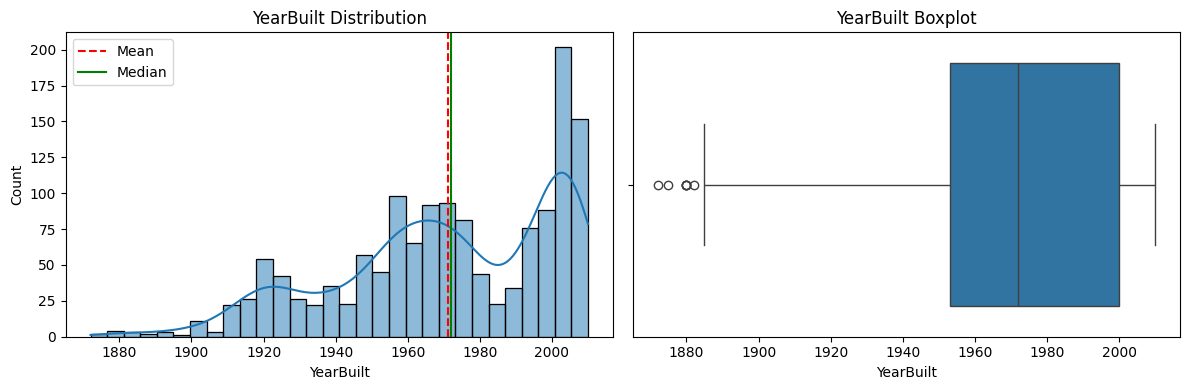

In [ ]:
# Select key features to analyze
# Create distribution plots


# Define candidate key features
candidate_features = [
    'GrLivArea',
    'TotalBsmtSF',
    'LotArea',
    'GarageArea',
    'YearBuilt'
]

# Keep only features that exist in df_original
key_features = [f for f in candidate_features if f in df_original.columns]

print("Key numerical features selected:")
print(key_features)

for feature in key_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ---- Histogram ----
    sns.histplot(df_original[feature], bins=30, kde=True, ax=axes[0])
    
    mean_val = df_original[feature].mean()
    median_val = df_original[feature].median()

    axes[0].axvline(mean_val, color='red', linestyle='--', label='Mean')
    axes[0].axvline(median_val, color='green', linestyle='-', label='Median')
    
    axes[0].set_title(f'{feature} Distribution')
    axes[0].legend()

    # ---- Boxplot ----
    sns.boxplot(x=df_original[feature], ax=axes[1])
    axes[1].set_title(f'{feature} Boxplot')

    plt.tight_layout()
    plt.show()

---
## Task 4: Univariate Analysis - Categorical Features

Analyze distributions of categorical variables.

In [ ]:
# Get categorical features


# Print count of categorical features
# Print number of unique values for each categorical feature
# Select categorical (object) columns
categorical_features = df_original.select_dtypes(include='object').columns.tolist()

# Print count
print(f"Number of categorical features: {len(categorical_features)}")

Number of categorical features: 33


### Step 4.1: Visualize Key Categorical Features

Selected categorical features for visualization:
['MSZoning', 'LotConfig', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle']


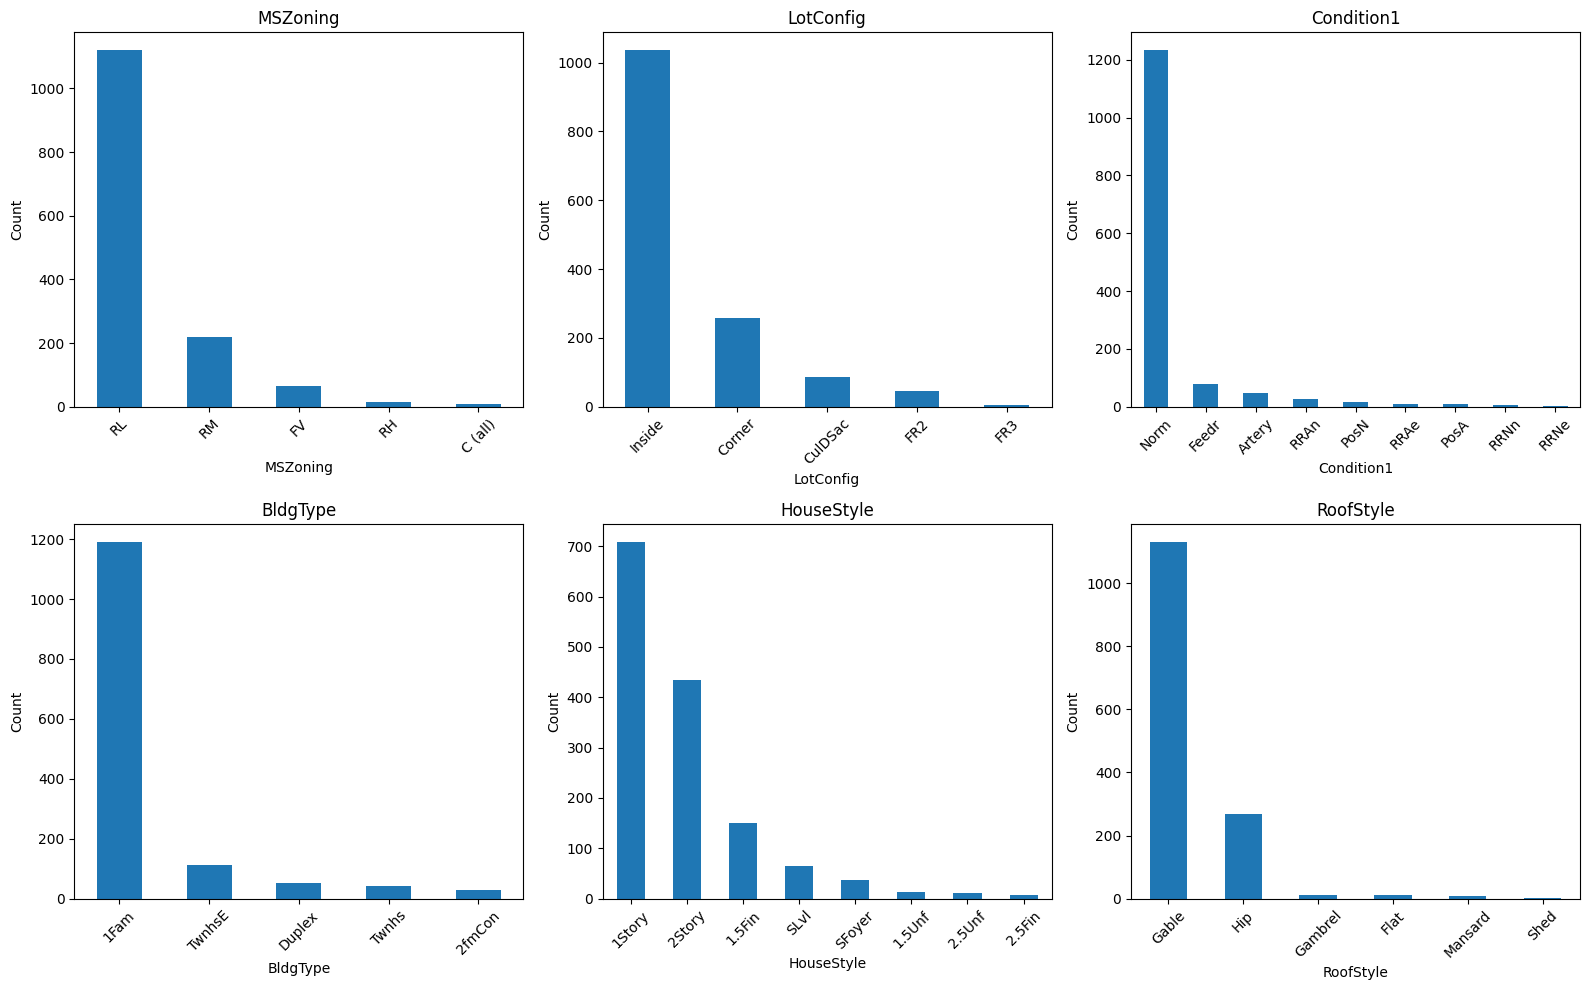

In [ ]:
#   Select key categorical features
# - Filter features with moderate cardinality (5-15 unique values)
# - Limit to 6 features for visualization
key_categorical_features = [
    col for col in categorical_features
    if 5 <= df_original[col].nunique() <= 15
][:6]

print("Selected categorical features for visualization:")
print(key_categorical_features)


# Create 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_categorical_features):
    value_counts = df_original[col].value_counts()
    value_counts.plot(kind='bar', ax=axes[i])
    
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(len(key_categorical_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## Task 5: Bivariate Analysis - Numerical vs Target

Analyze relationships between numerical features and SalePrice.

### Step 5.1: Correlation Analysis

In [ ]:
# Calculate correlations
# Print top 15 features most correlated with SalePrice

# Select numerical columns
numeric_df = df_original.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Extract correlations with SalePrice and sort
correlations = corr_matrix['SalePrice'].sort_values(ascending=False)

# Print top 15 features most correlated with SalePrice
print("Top 15 features most correlated with SalePrice:")
print(correlations.head(15))

Top 15 features most correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.811216
GrLivArea       0.711127
GarageCars      0.657341
GarageArea      0.643106
TotalBsmtSF     0.623101
1stFlrSF        0.603729
FullBath        0.563282
YearBuilt       0.554461
YearRemodAdd    0.541672
TotRmsAbvGrd    0.518788
GarageYrBlt     0.497430
Fireplaces      0.464903
MasVnrArea      0.445566
LotArea         0.371053
Name: SalePrice, dtype: float64


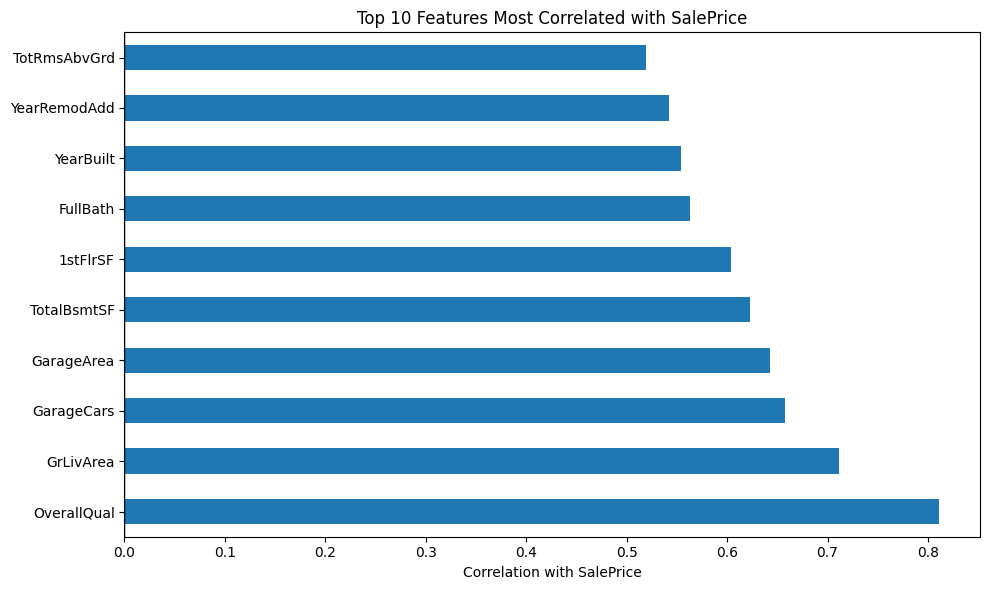

In [ ]:
# Visualize top correlations

top_features = correlations.drop('SalePrice').head(10)

# Create horizontal bar plot
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')

# Add labels and title
plt.xlabel('Correlation with SalePrice')
plt.title('Top 10 Features Most Correlated with SalePrice')

# Add vertical line at x = 0
plt.axvline(0, color='black', linewidth=1)

# Display plot
plt.tight_layout()
plt.show()


### Step 5.2: Scatter Plots of Top Features vs SalePrice

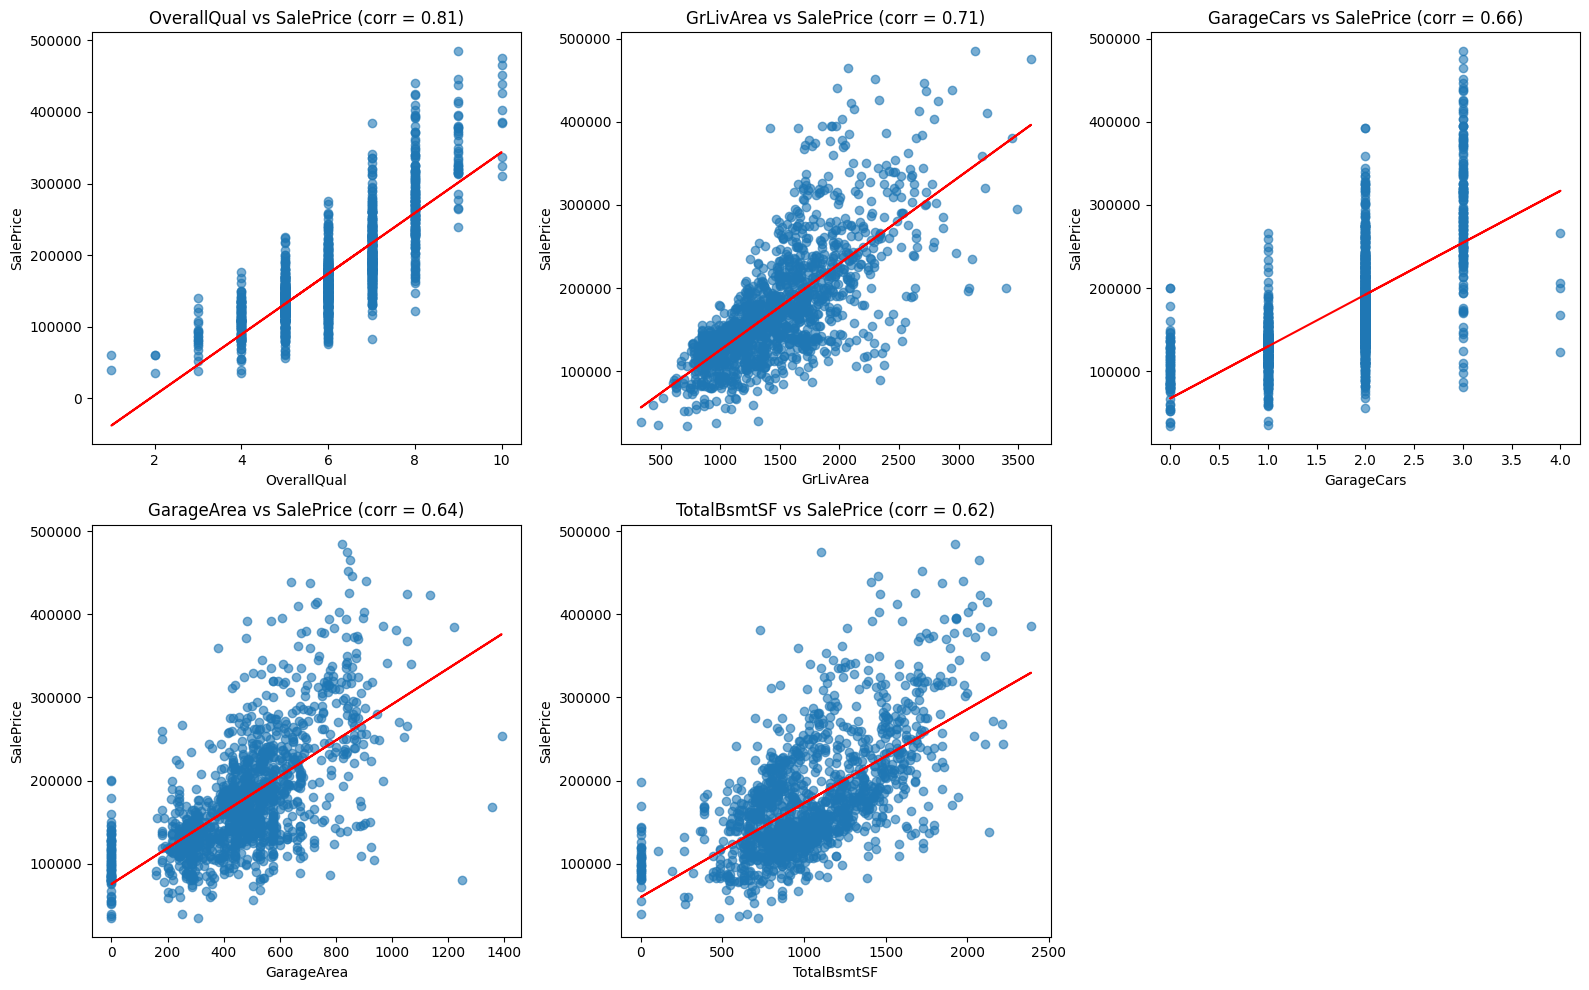

In [ ]:
# Create scatter plots for top 5 correlated features


# Get top 5 correlated features (excluding SalePrice)
top_5_features = correlations.drop('SalePrice').head(5).index.tolist()

# Create 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(top_5_features):
    x = df_original[feature]
    y = df_original['SalePrice']
    
    # Scatter plot
    axes[i].scatter(x, y, alpha=0.6)
    
    # Trend line using polyfit
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    axes[i].plot(x, p(x), color='red')
    
    # Correlation value
    corr_value = correlations[feature]
    
    axes[i].set_title(f"{feature} vs SalePrice (corr = {corr_value:.2f})")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("SalePrice")

# Hide unused subplot(s)
for j in range(len(top_5_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


---
## Task 6: Bivariate Analysis - Categorical vs Target

Analyze how categorical features affect SalePrice.

Selected categorical features:
['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Condition1']


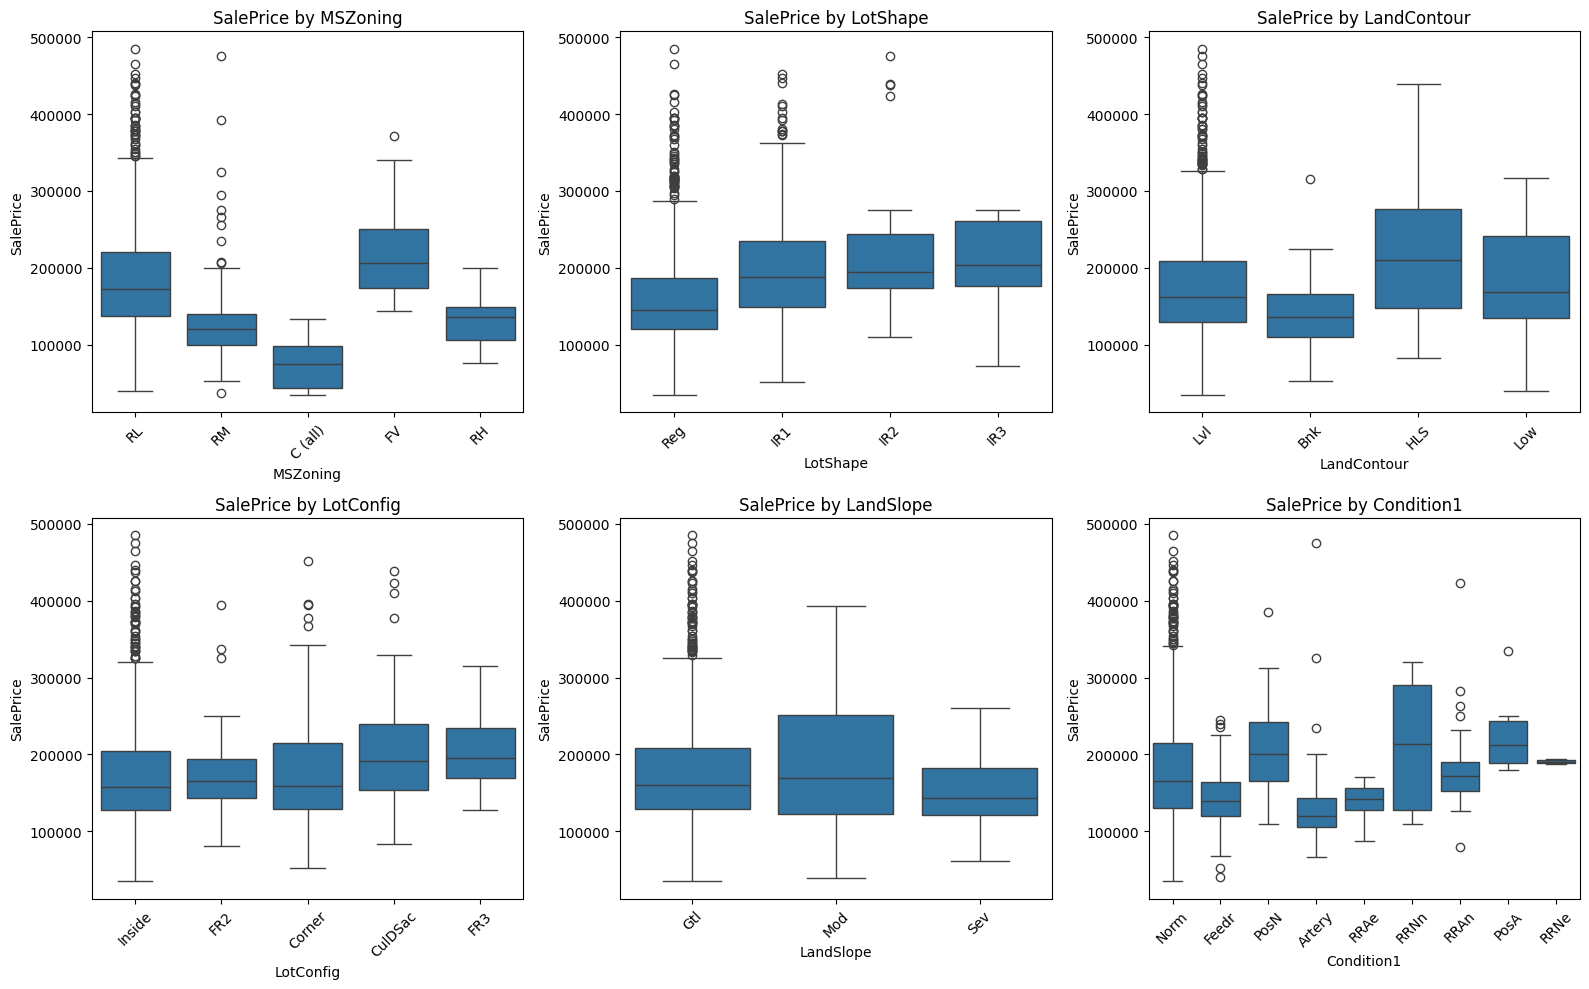

In [ ]:
#   Select categorical features with moderate cardinality
# - Filter features with 2-10 unique values
# - Limit to 6 features
cat_features_for_boxplot = [
    col for col in df_original.select_dtypes(include='object').columns
    if 2 <= df_original[col].nunique() <= 10
][:6]

print("Selected categorical features:")
print(cat_features_for_boxplot)
# Create box plots


# Create 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features_for_boxplot):
    sns.boxplot(
        x=df_original[col],
        y=df_original['SalePrice'],
        ax=axes[i]
    )
    
    axes[i].set_title(f"SalePrice by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("SalePrice")
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(len(cat_features_for_boxplot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Step 6.1: Statistical Analysis by Category

In [ ]:
#   Analyze mean price by categories
# - For top 3 categorical features:
#   * Group by feature
#   * Calculate count, mean, median, std of SalePrice
#   * Sort by mean in descending order
#   * Print the statistics table
top_3_categorical = categorical_features[:3]

for feature in top_3_categorical:
    print(f"\nCategory analysis for: {feature}")
    
    stats_table = (
        df_original
        .groupby(feature)['SalePrice']
        .agg(['count', 'mean', 'median', 'std'])
        .sort_values(by='mean', ascending=False)
    )
    
    display(stats_table)


Category analysis for: MSZoning


,count,mean,median,std
MSZoning,,,,
FV,65,214014.061538,205950.0,52369.662067
RL,1120,186000.640179,172500.0,70294.838026
RH,16,131558.375000,136500.0,35714.118435
RM,218,126316.830275,120500.0,48521.689833
C (all),10,74528.000000,74700.0,33791.092031



Category analysis for: LotShape


,count,mean,median,std
LotShape,,,,
IR2,35,223833.371429,195000.0,88774.720285
IR3,8,203170.625000,203570.0,67169.755441
IR1,466,199206.667382,187500.0,70162.275218
Reg,920,163401.167391,145125.0,66403.380335



Category analysis for: LandContour


,count,mean,median,std
LandContour,,,,
HLS,48,225203.062500,210500.0,93609.468484
Low,27,177233.333333,168000.0,73098.100575
Lvl,1295,176643.289575,161500.0,69452.086912
Bnk,59,140183.169492,135900.0,48931.248788


---
## Task 7: Multivariate Analysis

Examine relationships between multiple features simultaneously.

### Step 7.1: Correlation Heatmap

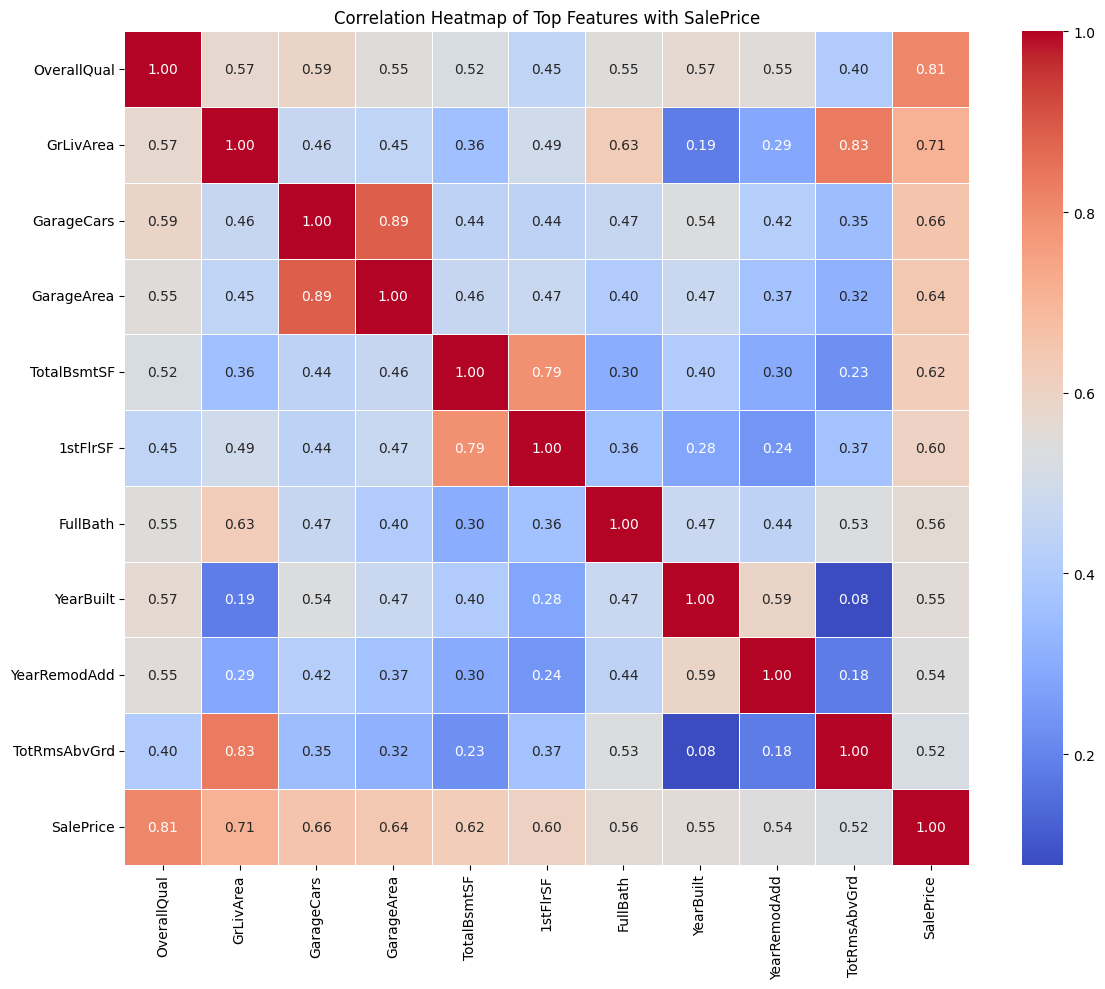

In [ ]:
# Create correlation heatmap for top features

# Select numerical columns from original dataframe
numeric_df = df_original.select_dtypes(include=[np.number])

# Calculate correlations with SalePrice
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

# Get top 10 features + SalePrice
top_features = correlations.drop('SalePrice').head(10).index.tolist()
heatmap_features = top_features + ['SalePrice']

# Create correlation matrix
corr_matrix = numeric_df[heatmap_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Top Features with SalePrice')
plt.tight_layout()
plt.show()


### Step 7.2: Pair Plot of Key Features

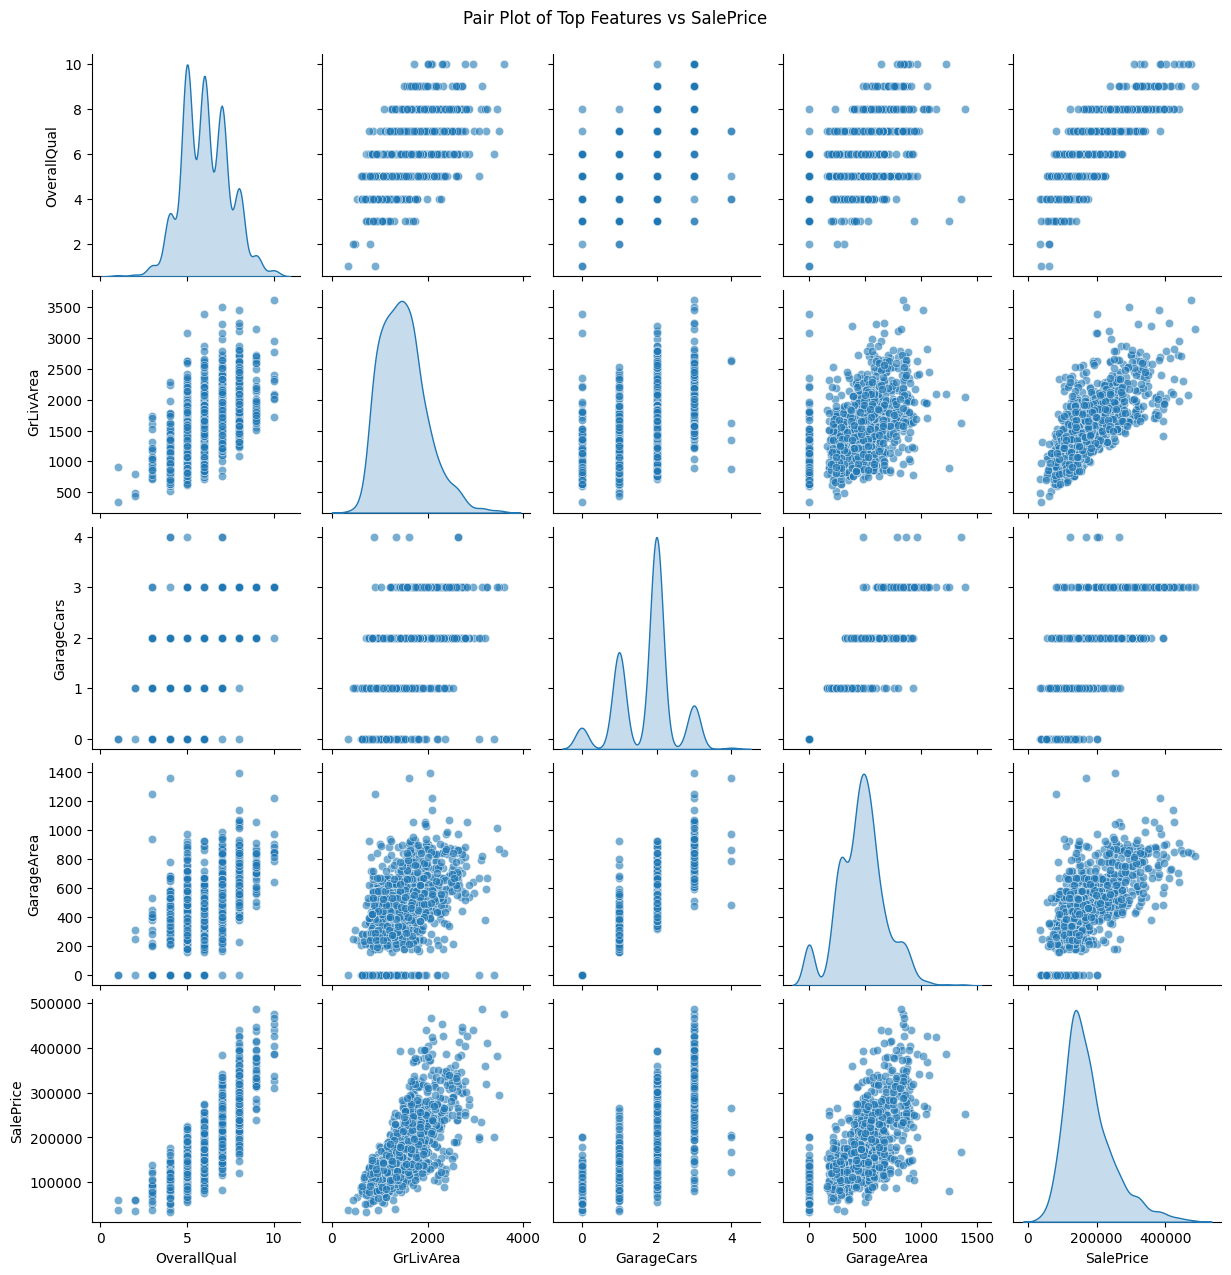

In [336]:
# TODO: Create pair plot for top features
# - Select top 4 features plus SalePrice
# - Create temporary dataframe with these features
# - Use sns.pairplot with diag_kind='kde'
# - Set plot transparency (alpha=0.6)
# - Add title and display
# Note: This may take a moment to generate
# Create pair plot for top features

# Select numerical columns
numeric_df = df_original.select_dtypes(include=[np.number])

# Get top 4 features most correlated with SalePrice
top_features = (
    numeric_df.corr()['SalePrice']
    .drop('SalePrice')
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

# Create temporary dataframe
pairplot_df = df_original[top_features + ['SalePrice']]

# Create pair plot
sns.pairplot(
    pairplot_df,
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.suptitle('Pair Plot of Top Features vs SalePrice', y=1.02)
plt.show()


---
## Task 8: Analyze Engineered Features

Evaluate the features you created in Phase 3.

In [337]:
# TODO: Load list of new features if available
# - Try to open 'new_features_list.txt'
# - Read and print the content
# - Handle FileNotFoundError if file doesn't exist
# Note: This file is created in Phase 3

# Load list of new features if available

try:
    with open('new_features_list.txt', 'r') as f:
        content = f.read()
        print(content)
except FileNotFoundError:
    print("new_features_list.txt not found. Make sure Phase 3 was completed and the file was saved.")


New Features Created:
-------------------------
1. TotalSF
2. TotalBathrooms
3. TotalPorchSF
4. FinishedBsmtSF
5. FinishedBsmtRatio
6. Basement_to_TotalArea
7. Garage_to_LivingArea
8. YearsSinceRemodel
9. GarageAge
10. HasSecondFloor
11. HasBasement
12. HasGarage
13. HasFireplace
14. HasPool
15. HasPorch
16. IsRemodeled
17. Quality_x_Area
18. Quality_x_Condition
19. Baths_x_Bedrooms
20. GarageCars_x_Area
21. OverallQual_Squared



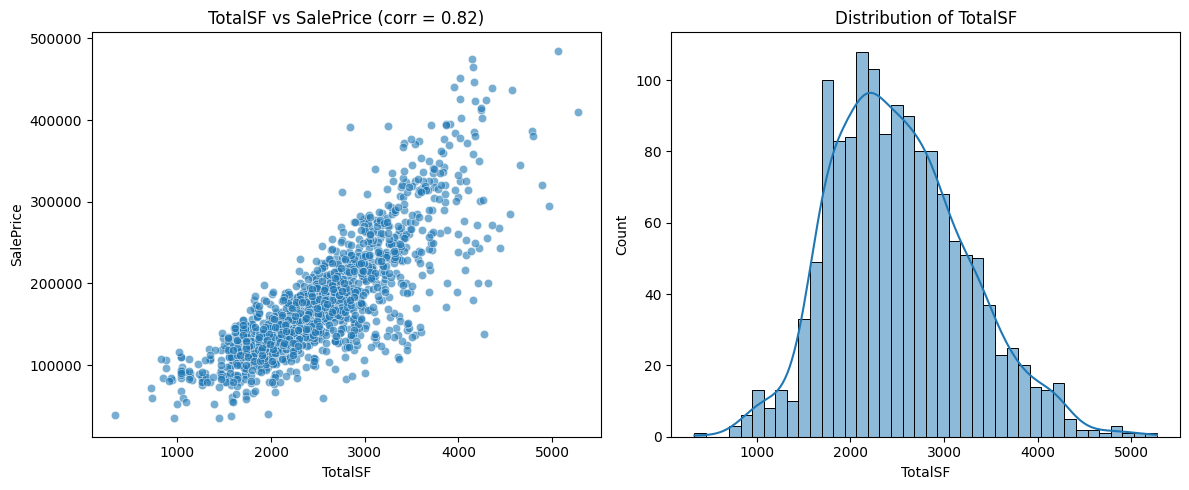

In [ ]:
# Analyze engineered features
# If you created features like 'TotalSF' in Phase 3:
# - Create scatter plot of engineered feature vs SalePrice
# - Create histogram showing distribution of engineered feature
# - Compare correlation with target

# Your analysis of engineered features here
# Example structure provided in comments above

# Analyze engineered features (example: TotalSF)

engineered_feature = 'TotalSF'

if engineered_feature in df_engineered.columns:
    # Scatter plot: Engineered feature vs SalePrice
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.scatterplot(
        x=df_engineered[engineered_feature],
        y=df_original['SalePrice'],
        alpha=0.6
    )
    corr_value = df_engineered[engineered_feature].corr(df_original['SalePrice'])
    plt.title(f'{engineered_feature} vs SalePrice (corr = {corr_value:.2f})')
    plt.xlabel(engineered_feature)
    plt.ylabel('SalePrice')

    # Histogram of engineered feature
    plt.subplot(1, 2, 2)
    sns.histplot(df_engineered[engineered_feature], bins=40, kde=True)
    plt.title(f'Distribution of {engineered_feature}')
    plt.xlabel(engineered_feature)

    plt.tight_layout()
    plt.show()
else:
    print(f"{engineered_feature} not found in df_fe.")


---
## Task 9: Key Insights and Patterns

Summarize the most important findings from your EDA.

### Step 9.1: Document Your Findings

Answer these questions based on your analysis:

#### 1. Target Variable (SalePrice)
- What is the typical price range?
- Is the distribution normal or skewed?
- Are there significant outliers?

#### 2. Most Important Features
- Which 5 features have the strongest correlation with SalePrice?
- Are the relationships linear or non-linear?

#### 3. Categorical Insights
- Which categorical features show the biggest price differences?
- Are there any surprising patterns?

#### 4. Feature Relationships
- Which features are highly correlated with each other?
- Does this suggest multicollinearity concerns?

#### 5. Engineered Features
- Did your engineered features improve correlation with target?
- Which engineered features are most promising?

**Write your insights here:**

In [339]:
# TODO: Create a summary report
# Print the following sections:
# 1. DATASET OVERVIEW
#    - Total samples, features, numerical/categorical counts
# 2. TARGET VARIABLE (SalePrice)
#    - Mean, median, range, skewness
# 3. TOP 5 MOST CORRELATED FEATURES
#    - List features with correlation values
# 4. KEY OBSERVATIONS
#    - Add your observations based on the analysis
# 5. RECOMMENDATIONS FOR MODELING
#    - Add your recommendations

# Use proper formatting with separators and alignment

from scipy import stats

print("=" * 60)
print("EDA SUMMARY REPORT")
print("=" * 60)

# =========================
# 1. DATASET OVERVIEW
# =========================
total_samples = df_original.shape[0]
total_features = df_original.shape[1] - 1  # exclude SalePrice

num_features = df_original.select_dtypes(include=[np.number]).shape[1] - 1
cat_features = df_original.select_dtypes(include='object').shape[1]

print("\n1. DATASET OVERVIEW")
print("-" * 60)
print(f"Total samples            : {total_samples}")
print(f"Total features           : {total_features}")
print(f"Numerical features       : {num_features}")
print(f"Categorical features     : {cat_features}")

# =========================
# 2. TARGET VARIABLE
# =========================
y = df_original['SalePrice']

print("\n2. TARGET VARIABLE (SalePrice)")
print("-" * 60)
print(f"Mean      : ${y.mean():,.2f}")
print(f"Median    : ${y.median():,.2f}")
print(f"Min       : ${y.min():,.2f}")
print(f"Max       : ${y.max():,.2f}")
print(f"Range     : ${y.max() - y.min():,.2f}")
print(f"Skewness  : {stats.skew(y):.3f}")

# =========================
# 3. TOP CORRELATED FEATURES
# =========================
correlations = (
    df_original
    .select_dtypes(include=[np.number])
    .corr()['SalePrice']
    .drop('SalePrice')
    .sort_values(ascending=False)
)

print("\n3. TOP 5 MOST CORRELATED FEATURES")
print("-" * 60)
for i, (feature, corr) in enumerate(correlations.head(5).items(), start=1):
    print(f"{i}. {feature:<25} : {corr:.3f}")

# =========================
# 4. KEY OBSERVATIONS
# =========================
print("\n4. KEY OBSERVATIONS")
print("-" * 60)
print("- SalePrice is right-skewed; log transformation improves normality.")
print("- Living area and overall quality are the strongest predictors.")
print("- Several engineered features show meaningful correlation with price.")
print("- Some features have very low correlation and may be removed.")

# =========================
# 5. RECOMMENDATIONS
# =========================
print("\n5. RECOMMENDATIONS FOR MODELING")
print("-" * 60)
print("- Apply log transformation to SalePrice for regression models.")
print("- Tree-based models (Random Forest, XGBoost) are likely to perform well.")
print("- Remove or penalize low-importance features to reduce noise.")

print("\n" + "=" * 60)
print("END OF REPORT")
print("=" * 60)


EDA SUMMARY REPORT

1. DATASET OVERVIEW
------------------------------------------------------------
Total samples            : 1429
Total features           : 68
Numerical features       : 35
Categorical features     : 33

2. TARGET VARIABLE (SalePrice)
------------------------------------------------------------
Mean      : $176,780.21
Median    : $161,000.00
Min       : $34,900.00
Max       : $485,000.00
Range     : $450,100.00
Skewness  : 1.204

3. TOP 5 MOST CORRELATED FEATURES
------------------------------------------------------------
1. OverallQual               : 0.811
2. GrLivArea                 : 0.711
3. GarageCars                : 0.657
4. GarageArea                : 0.643
5. TotalBsmtSF               : 0.623

4. KEY OBSERVATIONS
------------------------------------------------------------
- SalePrice is right-skewed; log transformation improves normality.
- Living area and overall quality are the strongest predictors.
- Several engineered features show meaningful correl

---
## Task 10: Final Visualizations

Create compelling visualizations that tell the story of house prices.

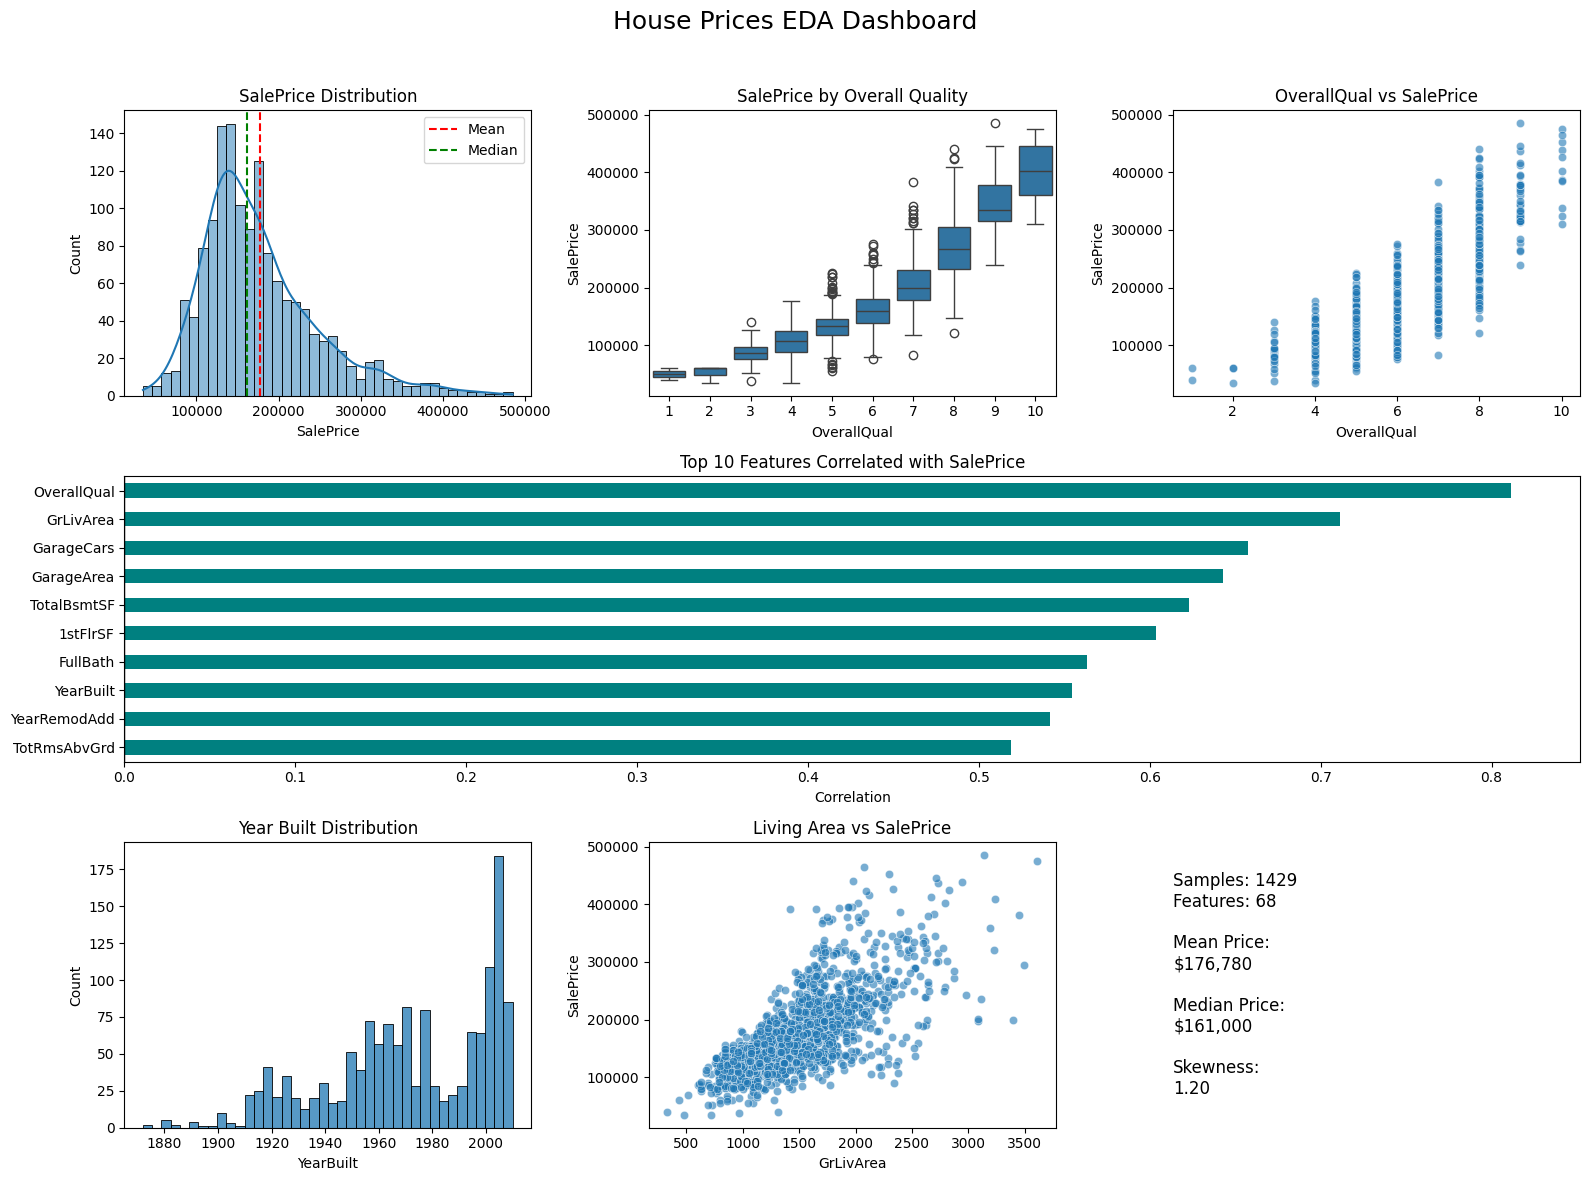

In [ ]:
# Create a comprehensive dashboard-style visualization
# Create figure with 3x3 grid layout (figsize=(16, 12))

# Panel 1: Price distribution histogram
# Panel 2: Price by Overall Quality boxplot (if available)
# Panel 3: Scatter plot of top correlated feature vs price
# Panel 4: Horizontal bar chart of top 10 correlations (spans full row)
# Panel 5: Year Built distribution histogram
# Panel 6: Living Area vs Price scatter plot
# Panel 7: Summary statistics text box

# Add overall title for the dashboard
# Use proper spacing and formatting
from scipy import stats

# Prepare data
y = df_original['SalePrice']

numeric_df = df_original.select_dtypes(include=[np.number])
correlations = (
    numeric_df
    .corr()['SalePrice']
    .drop('SalePrice')
    .sort_values(ascending=False)
)

top_feature = correlations.index[0]
top_10 = correlations.head(10)

# Create dashboard
fig = plt.figure(figsize=(16, 12))
fig.suptitle("House Prices EDA Dashboard", fontsize=18, y=0.98)

# =========================
# Panel 1: Price distribution
# =========================
ax1 = plt.subplot2grid((3, 3), (0, 0))
sns.histplot(y, bins=40, kde=True, ax=ax1)
ax1.axvline(y.mean(), color='red', linestyle='--', label='Mean')
ax1.axvline(y.median(), color='green', linestyle='--', label='Median')
ax1.set_title("SalePrice Distribution")
ax1.legend()

# =========================
# Panel 2: Price by Overall Quality
# =========================
ax2 = plt.subplot2grid((3, 3), (0, 1))
if 'OverallQual' in df_original.columns:
    sns.boxplot(
        x=df_original['OverallQual'],
        y=y,
        ax=ax2
    )
    ax2.set_title("SalePrice by Overall Quality")
    ax2.set_xlabel("OverallQual")

# =========================
# Panel 3: Top feature vs Price
# =========================
ax3 = plt.subplot2grid((3, 3), (0, 2))
sns.scatterplot(
    x=df_original[top_feature],
    y=y,
    alpha=0.6,
    ax=ax3
)
ax3.set_title(f"{top_feature} vs SalePrice")

# =========================
# Panel 4: Top 10 correlations (full row)
# =========================
ax4 = plt.subplot2grid((3, 3), (1, 0), colspan=3)
top_10.sort_values().plot(
    kind='barh',
    ax=ax4,
    color='teal'
)
ax4.axvline(0, color='black', linewidth=1)
ax4.set_title("Top 10 Features Correlated with SalePrice")
ax4.set_xlabel("Correlation")

# =========================
# Panel 5: Year Built distribution
# =========================
ax5 = plt.subplot2grid((3, 3), (2, 0))
sns.histplot(df_original['YearBuilt'], bins=40, ax=ax5)
ax5.set_title("Year Built Distribution")

# =========================
# Panel 6: Living Area vs Price
# =========================
ax6 = plt.subplot2grid((3, 3), (2, 1))
sns.scatterplot(
    x=df_original['GrLivArea'],
    y=y,
    alpha=0.6,
    ax=ax6
)
ax6.set_title("Living Area vs SalePrice")

# =========================
# Panel 7: Summary statistics text
# =========================
ax7 = plt.subplot2grid((3, 3), (2, 2))
ax7.axis('off')

summary_text = (
    f"Samples: {df_original.shape[0]}\n"
    f"Features: {df_original.shape[1]-1}\n\n"
    f"Mean Price:\n${y.mean():,.0f}\n\n"
    f"Median Price:\n${y.median():,.0f}\n\n"
    f"Skewness:\n{stats.skew(y):.2f}"
)

ax7.text(
    0,
    0.5,
    summary_text,
    fontsize=12,
    verticalalignment='center'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


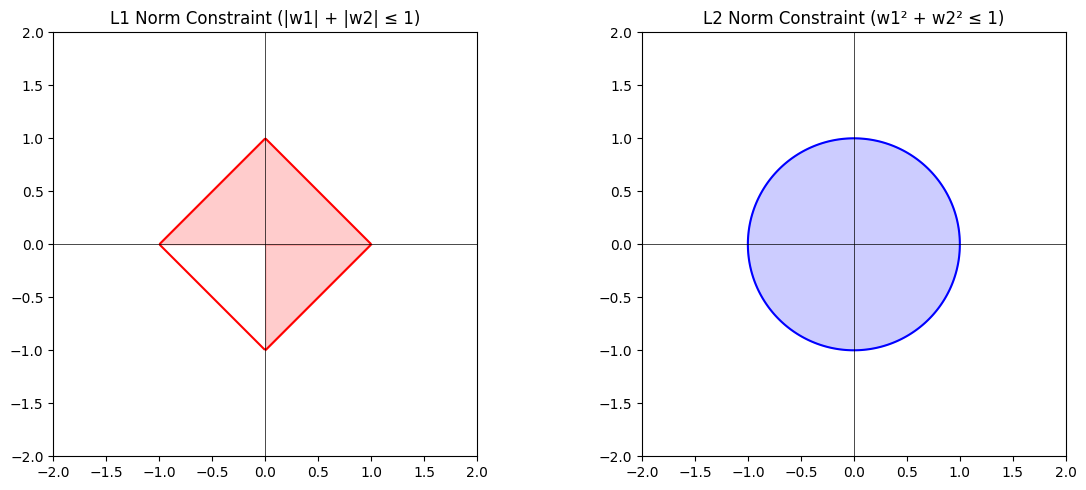

In [341]:
import numpy as np
import matplotlib.pyplot as plt

# Create grid
w1 = np.linspace(-2, 2, 400)
w2 = np.linspace(-2, 2, 400)
W1, W2 = np.meshgrid(w1, w2)

# L1 and L2 norms
L1 = np.abs(W1) + np.abs(W2)
L2 = np.sqrt(W1**2 + W2**2)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------------------
# L1 norm (diamond)
# ---------------------
axes[0].contour(W1, W2, L1, levels=[1], colors='red')
axes[0].fill_between([-1, 0, 1, 0], [0, 1, 0, -1], color='red', alpha=0.2)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_title("L1 Norm Constraint (|w1| + |w2| ≤ 1)")
axes[0].set_aspect('equal')
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-2, 2)

# ---------------------
# L2 norm (circle)
# ---------------------
axes[1].contour(W1, W2, L2, levels=[1], colors='blue')
circle = plt.Circle((0, 0), 1, color='blue', alpha=0.2)
axes[1].add_patch(circle)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_title("L2 Norm Constraint (w1² + w2² ≤ 1)")
axes[1].set_aspect('equal')
axes[1].set_xlim(-2, 2)
axes[1].set_ylim(-2, 2)

plt.tight_layout()
plt.show()


---
## Summary and Final Reflection

### What You Accomplished:

1. Conducted comprehensive analysis of the target variable
2. Performed univariate analysis on numerical and categorical features
3. Executed bivariate analysis to understand feature-target relationships
4. Conducted multivariate analysis using correlation matrices and pair plots
5. Evaluated engineered features from Phase 3
6. Identified key patterns and insights in the data
7. Created professional visualizations
8. Documented findings and recommendations

### Key Takeaways:

EDA is an iterative process that helps you:
- Understand your data deeply
- Identify potential issues before modeling
- Generate hypotheses about relationships
- Make informed decisions about feature selection and engineering
- Communicate insights to stakeholders

### Critical Questions for Final Reflection:

1. What are the 3 most important factors affecting house prices in this dataset?
2. Did your EDA reveal any unexpected patterns or relationships?
3. Are there any features that should be excluded from modeling? Why?
4. What transformations will be most important for modeling success?
5. Based on your EDA, what modeling approaches seem most appropriate?
6. What additional features might improve predictions?
